## Обратная задача для уравнения теплопроводности

Цель: восстановить начальное распределение температуры `u0(x)` по известному конечному состоянию `u(x, T)`.

В работе используется:
- решение прямой задачи (конечно-разностная схема)
- дискретное синусное преобразование (DST)
- регуляризация Тихонова
- восстановление начальной функции (IDST)


# Теоретическая часть

##  Прямая задача

Рассматривается начально‑краевая задача для уравнения теплопроводности:
$$
u_t = a^2 u_{xx} \qquad (x,t) \in (0,l) \times (0,T)
$$
Начальное условие:
$$
u(x,0) = u_0(x)
$$
Граничные условия:
$$
u(0,t)=0 \qquad u(l,t)=0 \qquad t \in [0,T]
$$
Известно, что решение можно представить в виде ряда Фурье:
$$
u(x,t) = \sum c_n * e^{-\lambda_n a^2 t} sin(\frac{\pi nx}{l})
$$
где
$$
c_n = (\frac{2}{l}) \int_0^l u_0(x) sin(\frac{\pi nx}{l}) dx
$$
$$
\lambda_n = \frac{\pi^2 n^2}{l^2}
$$
---

## Обратная задача

Необходимо восстановить начальное распределение температуры $u_0(x)$, если известно конечное состояние системы:
$$
u(x,T)
$$
Из решения следует, что коэффициенты Фурье для $u(x,T)$:
$$
d_n = c_n e^{-\lambda_n a^2T}
$$
Следовательно
$$
c_n = d_n e^{\lambda_n a^2T}
$$
Однако такое восстановление является **неустойчивым**, поскольку малые ошибки в $d_n$ приводят к экспоненциальному росту ошибки в $c_n$.

Это связано с тем, что $\lambda_n \sim n^2$ и высокочастотные гармоники быстро усиливают шум.

## Регуляризация Тихонова

Для стабилизации решения применяется регуляризация Тихонова.
Экспоненциальный множитель заменяется фильтрующей функцией:
$$
H_\alpha(\lambda_n) = \frac{e^{\lambda_n a^2T}}{1 + \alpha e^{2 \lambda_n a^2 T}}
$$
где $α$ — параметр регуляризации.

Свойства:

1. $ H_\alpha(\lambda_n) \to e^{\lambda_n a^2T} $ при $\alpha\to 0 $
2. $ H_\alpha(\lambda_n) \approx \frac{1}{\alpha}e^{-\lambda_n a^2T} \to 0 $ для высоких частот $ \sqrt{\lambda_n} $ (при $ n \to \infty $)
3. $ H_\alpha(\lambda_n) \approx e^{\lambda_n\ a^2T} $ для низких частот

То есть высокие частоты "подавляются", а низкие практически не искажаются

Таким образом регуляризация позволяет получить устойчивое приближение
начальной функции.

# Практическая часть

## Импорт библиотек
Нам понадобятся библиотеки для:
- численных вычислений
- построения графиков
- синусных преобразований

In [38]:
# numpy — работа с массивами и численные вычисления
import numpy as np

# matplotlib — построение графиков
import matplotlib.pyplot as plt

# из scipy используем DST и обратное DST
# DST — дискретное синусное преобразование
# IDST — обратное синусное преобразование
from scipy.fft import dst, idst
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 12

## Параметры задачи
Задаём параметры области и сетки.

In [39]:
# длина стержня
l = 1

# конечное время
T = 0.05

# коэффициент теплопроводности
a = 1

# число узлов по пространству
Nx = 50

# число шагов по времени
Nt = 2000

# шаг по пространству
dx = l / Nx

# шаг по времени
dt = T / Nt

# координаты пространственной сетки
x = np.linspace(0, l, Nx+1)

## Начальная функция
Выбираем тестовую функцию $ u_0(x) $

Она используется только для генерации данных прямой задачи.
Затем мы будем пытаться восстановить её по конечному состоянию.

In [40]:
# функция начального распределения температуры
def initial_function(x):
    return -1 * ((x >= 0.2) & (x < 0.4)) + 2 * ((x >= 0.6) & (x < 0.8))
    #return x*(1-x)

# создаём массив для хранения решения
# строки — время
# столбцы — координата
u = np.zeros((Nt+1, Nx+1))

# задаём начальное условие
u[0,:] = initial_function(x)

# граничные условия
# температура на концах стержня равна нулю
u[:,0] = 0
u[:,-1] = 0

## Решение прямой задачи
Используем явную конечно-разностную схему.

In [41]:
# Проверка условия Куранта
assert a**2 * dt < dx**2 / 2


r = a**2 * dt / dx**2
# основной цикл по времени
for n in range(Nt):
    
    # цикл по пространству
    # пропускаем граничные точки
    for i in range(1, Nx):
        
        # явная разностная схема
        u[n+1,i] = u[n,i] + r*(u[n,i+1] - 2*u[n,i] + u[n,i-1])

# конечное состояние системы
uT = u[-1,:]

## График конечного состояния

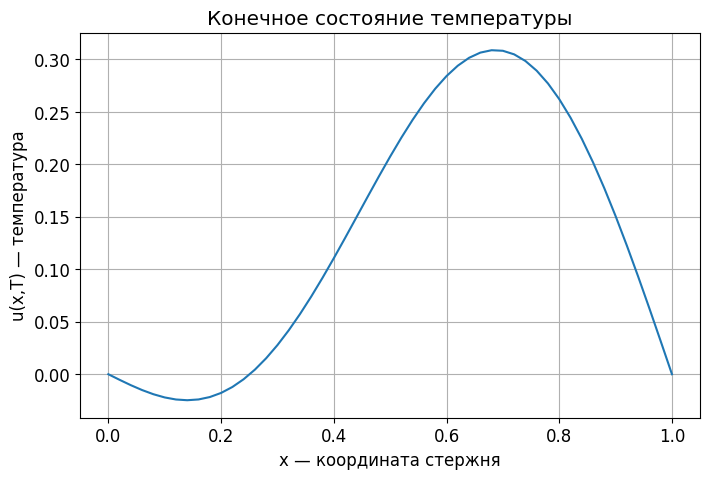

In [42]:
plt.figure()

plt.plot(x, uT)

plt.title("Конечное состояние температуры")
plt.xlabel("x — координата стержня")
plt.ylabel("u(x,T) — температура")

plt.grid()
plt.show()

## DST преобразование
Находим коэффициенты Фурье для функции `u(x,T)`.

In [43]:
# используем внутренние точки (без границ)
d = dst(uT[1:-1], type=1)

## Регуляризация Тихонова
Используем фильтр для подавления высокочастотных компонент.

In [44]:
# номера гармоник
n = np.arange(1, Nx)

# собственные значения оператора
lam = (np.pi*n/l)**2

# параметр регуляризации
alpha = 1e-3

# вычисление коэффициентов
# формула переписана в устойчивом виде
c = d * np.exp(lam*a**2*T) / (1 + alpha*np.exp(2*lam*a**2*T))   
c[np.isnan(c)] = 0

C:\Users\yaggod\AppData\Local\Temp\ipykernel_16952\3423171930.py:12: RuntimeWarning: overflow encountered in exp
  c = d * np.exp(lam*a**2*T) / (1 + alpha*np.exp(2*lam*a**2*T))
C:\Users\yaggod\AppData\Local\Temp\ipykernel_16952\3423171930.py:12: RuntimeWarning: invalid value encountered in multiply
  c = d * np.exp(lam*a**2*T) / (1 + alpha*np.exp(2*lam*a**2*T))
C:\Users\yaggod\AppData\Local\Temp\ipykernel_16952\3423171930.py:12: RuntimeWarning: invalid value encountered in divide
  c = d * np.exp(lam*a**2*T) / (1 + alpha*np.exp(2*lam*a**2*T))


## Восстановление начальной функции

In [45]:
# создаём массив для восстановленной функции
u0_rec = np.zeros(Nx+1)

# применяем обратное синусное преобразование
u0_rec[1:-1] = idst(c, type=1)

## Сравнение решений

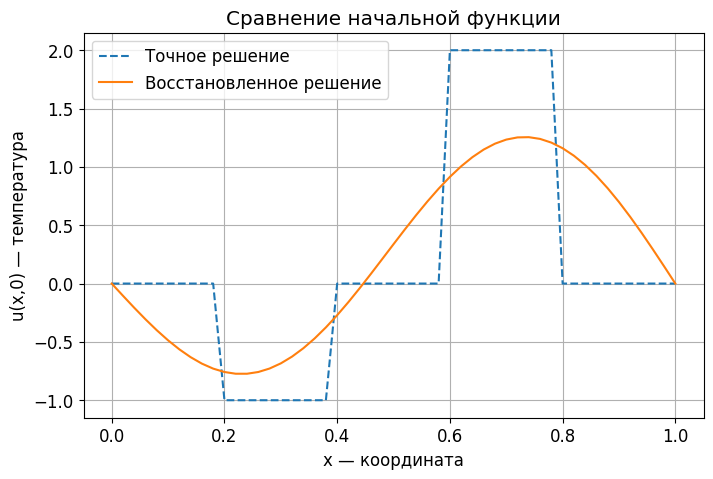

In [46]:
plt.figure()

plt.plot(x, initial_function(x), '--', label='Точное решение')
plt.plot(x, u0_rec, label='Восстановленное решение')

plt.title("Сравнение начальной функции")
plt.xlabel("x — координата")
plt.ylabel("u(x,0) — температура")

plt.legend()
plt.grid()
plt.show()

## Исследование параметра регуляризации
Сравним результаты для разных значений α.

C:\Users\yaggod\AppData\Local\Temp\ipykernel_16952\2004021505.py:9: RuntimeWarning: overflow encountered in exp
  c = d * np.exp(lam*a**2*T) / (1 + alpha*np.exp(2*lam*a**2*T))
C:\Users\yaggod\AppData\Local\Temp\ipykernel_16952\2004021505.py:9: RuntimeWarning: invalid value encountered in multiply
  c = d * np.exp(lam*a**2*T) / (1 + alpha*np.exp(2*lam*a**2*T))
C:\Users\yaggod\AppData\Local\Temp\ipykernel_16952\2004021505.py:9: RuntimeWarning: invalid value encountered in divide
  c = d * np.exp(lam*a**2*T) / (1 + alpha*np.exp(2*lam*a**2*T))


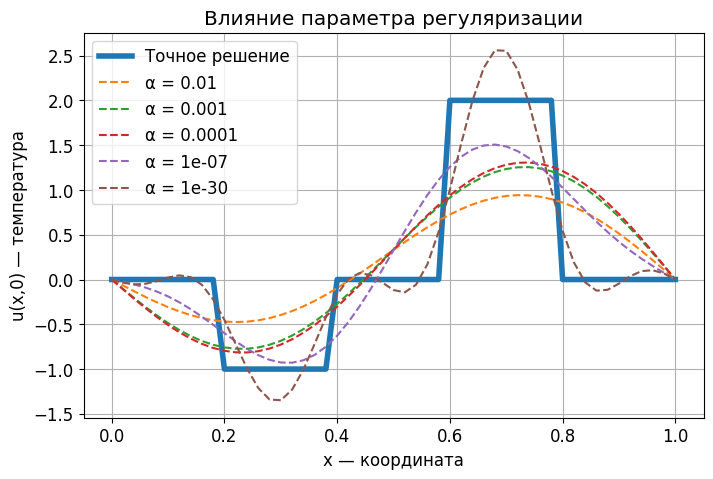

In [47]:
alphas = [1e-2, 1e-3, 1e-4, 1e-7, 1e-30]

plt.figure()

plt.plot(x, initial_function(x), label='Точное решение', linewidth=4)

for alpha in alphas:

    c = d * np.exp(lam*a**2*T) / (1 + alpha*np.exp(2*lam*a**2*T))   
    c[np.isnan(c)] = 0

    u0_tmp = np.zeros(Nx+1)
    u0_tmp[1:-1] = idst(c, type=1)

    plt.plot(x, u0_tmp, '--', label=f'α = {alpha}')

plt.title("Влияние параметра регуляризации")
plt.xlabel("x — координата")
plt.ylabel("u(x,0) — температура")

plt.legend()
plt.grid()
plt.show()

## Вывод
В лабораторной работе была исследована обратная задача для уравнения теплопроводности.

Было показано, что без регуляризации задача является неустойчивой.
Использование регуляризации Тихонова позволяет подавить высокочастотные ошибки и восстановить начальную функцию.